<a href="https://colab.research.google.com/github/Gus-oss/COVID-19/blob/main/Covid_19V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis sobre base de datos de covid19 en México durante la pandemia.
Autor: Gustavo de Jesús Escobar Mata


Este Nootebook se centrara en realizar un estudio de acuerdo a los datos recapitulados sobre la pandemia del covid-19 en México.
Los datos fueron recapitulados de la pagina : https://www.gob.mx/salud/documentos/datos-abiertos-152127 a la fecha: 08/09/2024

En este nootbook vamos a limpiar los datos de manera que toda la información que esten en los otros documentos aparezcan en el documento principal.

Primero se procedio a subir todos los documentos a Google colab.

In [ ]:
#Importamos las librerias que utilizaremos a lo largo del documento
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

#cargar el dataset del covid

#******************************************************************************
#Dataframe del covid
url_covid = '/content/COVID19MEXICO.csv' #Tambien se puede importar por url
df_covid = pd.read_csv(url_covid)
#******************************************************************************

#******************************************************************************
#dataframe del catalogo
url_catalogos ='/content/240708 Catalogos.xlsx'
#lo convertimos en un archivo de excel
excel_file_catalagos = pd.ExcelFile(url_catalogos)
#******************************************************************************
#******************************************************************************
#Dataframe de los descriptores
#cargar el dataset de los descriptores
url_descriptores = '/content/240708 Descriptores_.xlsx'
df_descriptores = pd.read_excel(url_descriptores)
#******************************************************************************

#visaulizacion de los dataset
df_covid.head() #muestra las primeras filas para una vista general


,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,1,10,9,2,15,9,3,1,...,5,5,2,97,7,7,99,México,97,97
1,2024-10-22,g9637c9,1,4,25,1,25,25,12,2,...,10,998,2,97,7,7,99,México,97,2
2,2024-10-22,gdb0743,1,3,19,2,19,19,39,1,...,5,5,2,97,7,7,99,México,97,97
3,2024-10-22,gd16cbd,1,15,32,1,32,32,17,1,...,34,998,2,97,3,7,99,México,97,97
4,2024-10-22,g6cb0c4,1,12,29,1,29,29,33,2,...,1,998,2,97,7,3,99,México,97,2


# Limpieza de datos
 La limpieza de datos es un paso crucial para asegurar que el analisis sea presiso y confiable . Aqui manejamos valores nulos y eliminaremos duplicados.

 En esta limpieza vamos a remplasar todos los valores numericos como "Sexo" que tienen 1 para hombre y 2 para mujer para tener toda la informacion en el df_covid principal sin necesidad de utilizar los otros documentos

In [ ]:
# 1. Revisión de valores faltantes (NaN)
# Verificamos cuántos valores faltantes hay por columna
valores_nulos = df_covid.isnull().sum()
print("Valores faltantes por columna:\n", valores_nulos)

Valores faltantes por columna:
 FECHA_ACTUALIZACION          0
ID_REGISTRO                  0
ORIGEN                       0
SECTOR                       0
ENTIDAD_UM                   0
SEXO                         0
ENTIDAD_NAC                  0
ENTIDAD_RES                  0
MUNICIPIO_RES                0
TIPO_PACIENTE                0
FECHA_INGRESO                0
FECHA_SINTOMAS               0
FECHA_DEF                    0
INTUBADO                     0
NEUMONIA                     0
EDAD                         0
NACIONALIDAD                 0
EMBARAZO                     0
HABLA_LENGUA_INDIG           0
INDIGENA                     0
DIABETES                     0
EPOC                         0
ASMA                         0
INMUSUPR                     0
HIPERTENSION                 0
OTRA_COM                     0
CARDIOVASCULAR               0
OBESIDAD                     0
RENAL_CRONICA                0
TABAQUISMO                   0
OTRO_CASO                    0
TOMA_MU

No hay valores nulos en las columnas del dataset

In [ ]:
# 2. Revisión de datos inconsistentes o erróneos
# Por ejemplo, asegurémonos de que las edades estén en un rango lógico (0-120)
df_covid = df_covid[(df_covid['EDAD'] >= 0) & (df_covid['EDAD'] <= 120)]

In [ ]:
# 3. Eliminar duplicados
# Revisamos si hay filas duplicadas y las eliminamos si las encontramos
df_covid = df_covid.drop_duplicates()

In [ ]:
# 4. Revisión de tipos de datos
# Convertimos las columnas de fecha a formato datetime para análisis temporal
df_covid['FECHA_INGRESO'] = pd.to_datetime(df_covid['FECHA_INGRESO'], errors='coerce')
df_covid['FECHA_SINTOMAS'] = pd.to_datetime(df_covid['FECHA_SINTOMAS'], errors='coerce')
df_covid['FECHA_DEF'] = pd.to_datetime(df_covid['FECHA_DEF'], errors='coerce')

<ipython-input-5-7c63ea935cb2>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_covid['FECHA_DEF'] = pd.to_datetime(df_covid['FECHA_DEF'], errors='coerce')


In [ ]:
#Esto es lo que hay que cambiar para que en lugar de sea manual tenga que ser
# automatico, es decir que agarre los datos del catalogo y que los intercambier
# por los datos que se encuentran en el dataframe del covid

# 5. Codificación de valores categóricos
# Reemplazamos valores numéricos por etiquetas, por ejemplo, en la columna SEXO
df_covid['SEXO'] = df_covid['SEXO'].replace({1: 'Hombre', 2: 'Mujer', 99: 'No Especificado'})

#Remplazamos valores numericos por etiquetas en la columna Origen
df_covid['ORIGEN'] = df_covid['ORIGEN'].replace({1: 'usmer', 2: 'Fuera de usmer', 99: 'No Especificado'})

# Las USMERs son centros de salud y hospitales ubicados en puntos estratégicos con la capacidad de realizar
# vigilancia de enfermedades respiratorias

#Remplazamos valores numericos por etiquetas en la comuna de Tipo_Paciente
df_covid['TIPO_PACIENTE'] = df_covid['TIPO_PACIENTE'].replace({1: 'Ambulatorio', 2: 'Hospitalizado', 99: 'No Especificado'})


#Remplazamos valores numericos por etiquetas en la comuna TOMA_MUESTRA_ANTIGENO
df_covid['TOMA_MUESTRA_ANTIGENO'] = df_covid['TOMA_MUESTRA_ANTIGENO'].replace({
    1: 'Si',
    2: 'No',
    97: 'No Aplica',
    98: 'Se ignora',
    99: 'No especificado'})


#Remplazamos valores numericos por etiquetas en la comuna RESULTADO_ANTIGENO
df_covid['RESULTADO_ANTIGENO'] = df_covid['RESULTADO_ANTIGENO'].replace({
    1: 'Positivo a Sars-cov-2',
    2: 'Negativo a Sars-cov-2',
    97:'No Aplica (caso sin muestra)'})


# Reemplazamos valores numéricos por etiquetas, por ejemplo, en la columna CLASIFICACION_FINAL_COVID
df_covid['CLASIFICACION_FINAL_COVID'] = df_covid['CLASIFICACION_FINAL_COVID'].replace({
    1: 'Caso de Covid-19 confirmado por asociación clínica epidemica',
    2: 'Caso de Covid_19 confirmado por comité de dictamen ',
    3: 'Caso de Sars-COV-2 confirmado',
    4: 'Invalido por laboratorio',
    5: 'No realizado por laboratorio',
    6: 'Caso sospechoso',
    7: 'Negativo a Sars-cov-2'})


# Reemplazamos valores numéricos por etiquetas, por ejemplo, en la columna MIGRANTE
df_covid['MIGRANTE'] = df_covid['MIGRANTE'].replace({
    1: 'Si', 2: 'No', 97: 'No Aplica', 98: 'Se ignora', 99: 'No especificado'})

#Remplazamos valores numericos por etiquetas en la columna de UCI
df_covid['UCI'] = df_covid['UCI'].replace({
    1: 'Si', 2: 'No', 97: 'No Aplica', 98: 'Se ignora', 99: 'No especificado'})

In [ ]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,usmer,10,9,Mujer,15,9,3,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-10-22,g9637c9,usmer,4,25,Hombre,25,25,12,Hospitalizado,...,10,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No
2,2024-10-22,gdb0743,usmer,3,19,Mujer,19,19,39,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-10-22,gd16cbd,usmer,15,32,Hombre,32,32,17,Ambulatorio,...,34,998,No,No Aplica (caso sin muestra),Caso de Sars-COV-2 confirmado,7,No especificado,México,97,No Aplica
4,2024-10-22,g6cb0c4,usmer,12,29,Hombre,29,29,33,Hospitalizado,...,1,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,3,No especificado,México,97,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145706,2024-10-22,gb402a3,usmer,15,32,Hombre,32,32,16,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145707,2024-10-22,g9182d2,usmer,6,25,Mujer,25,25,6,Ambulatorio,...,997,997,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No Aplica
145708,2024-10-22,ga31992,usmer,3,21,Mujer,21,21,114,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145709,2024-10-22,g932570,usmer,3,21,Hombre,30,21,114,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [ ]:
#  Ahora realizaremos lo mismo pero para las entidades
#  pero de forma automatizada
# Extraemos el catálogo de entidades
df_enti = pd.read_excel(excel_file_catalagos, sheet_name='Catálogo de ENTIDADES')
df_enti

,CLAVE_ENTIDAD,ENTIDAD_FEDERATIVA,ABREVIATURA
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [ ]:
df_enti["CLAVE_ENTIDAD"].values[0]

1

In [ ]:
for i in range(len(df_covid['ENTIDAD_RES'])):
    y_enti = df_covid['ENTIDAD_RES'].iloc[i]

    # Verifica si y_enti es un número válido antes de usarlo
    if pd.notna(y_enti):  # Asegúrate de que no sea NaN
        x_clave = df_enti[df_enti['CLAVE_ENTIDAD'].isin([y_enti])]  # Asegúrate de pasarle una lista
        if not x_clave.empty:  # Verifica si x_clave tiene algún resultado
            estado = x_clave.iloc[0]['ENTIDAD_FEDERATIVA']
            df_covid['ENTIDAD_RES'].iloc[i] = estado

#Este proceso puede tardar un poco, pero es por que tiene que ir acmbiando todoas
#linas y son mas de 100,000

<ipython-input-10-fb0b53e9a5d7>:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_covid['ENTIDAD_RES'].iloc[i] = estado
<ipython-input-10-fb0b53e9a5d7>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [ ]:
df_covid['ENTIDAD_RES']

,ENTIDAD_RES
0,CIUDAD DE MÉXICO
1,SINALOA
2,NUEVO LEÓN
3,ZACATECAS
4,TLAXCALA
...,...
145706,ZACATECAS
145707,SINALOA
145708,PUEBLA
145709,PUEBLA


In [ ]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,usmer,10,9,Mujer,15,CIUDAD DE MÉXICO,3,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-10-22,g9637c9,usmer,4,25,Hombre,25,SINALOA,12,Hospitalizado,...,10,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No
2,2024-10-22,gdb0743,usmer,3,19,Mujer,19,NUEVO LEÓN,39,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-10-22,gd16cbd,usmer,15,32,Hombre,32,ZACATECAS,17,Ambulatorio,...,34,998,No,No Aplica (caso sin muestra),Caso de Sars-COV-2 confirmado,7,No especificado,México,97,No Aplica
4,2024-10-22,g6cb0c4,usmer,12,29,Hombre,29,TLAXCALA,33,Hospitalizado,...,1,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,3,No especificado,México,97,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145706,2024-10-22,gb402a3,usmer,15,32,Hombre,32,ZACATECAS,16,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145707,2024-10-22,g9182d2,usmer,6,25,Mujer,25,SINALOA,6,Ambulatorio,...,997,997,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No Aplica
145708,2024-10-22,ga31992,usmer,3,21,Mujer,21,PUEBLA,114,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145709,2024-10-22,g932570,usmer,3,21,Hombre,30,PUEBLA,114,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [ ]:
# Ahora vamos a hacer lo mismo pero con "ENTIDAD_NAC"
for i in range(len(df_covid['ENTIDAD_NAC'])):
    y_nac = df_covid['ENTIDAD_NAC'].iloc[i]

    # Verifica si y_nac es un número válido antes de usarlo
    if pd.notna(y_nac):  # Asegúrate de que no sea NaN
        x_clave = df_enti[df_enti['CLAVE_ENTIDAD'].isin([y_nac])]  # Asegúrate de pasarle una lista
        if not x_clave.empty:  # Verifica si x_clave tiene algún resultado
            nac = x_clave.iloc[0]['ENTIDAD_FEDERATIVA']
            df_covid['ENTIDAD_NAC'].iloc[i] = nac

<ipython-input-13-07ee0f56b353>:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_covid['ENTIDAD_NAC'].iloc[i] = nac
<ipython-input-13-07ee0f56b353>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [ ]:
df_covid['ENTIDAD_NAC']

,ENTIDAD_NAC
0,MÉXICO
1,SINALOA
2,NUEVO LEÓN
3,ZACATECAS
4,TLAXCALA
...,...
145706,ZACATECAS
145707,SINALOA
145708,PUEBLA
145709,VERACRUZ DE IGNACIO DE LA LLAVE


In [ ]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,usmer,10,9,Mujer,MÉXICO,CIUDAD DE MÉXICO,3,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-10-22,g9637c9,usmer,4,25,Hombre,SINALOA,SINALOA,12,Hospitalizado,...,10,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No
2,2024-10-22,gdb0743,usmer,3,19,Mujer,NUEVO LEÓN,NUEVO LEÓN,39,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-10-22,gd16cbd,usmer,15,32,Hombre,ZACATECAS,ZACATECAS,17,Ambulatorio,...,34,998,No,No Aplica (caso sin muestra),Caso de Sars-COV-2 confirmado,7,No especificado,México,97,No Aplica
4,2024-10-22,g6cb0c4,usmer,12,29,Hombre,TLAXCALA,TLAXCALA,33,Hospitalizado,...,1,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,3,No especificado,México,97,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145706,2024-10-22,gb402a3,usmer,15,32,Hombre,ZACATECAS,ZACATECAS,16,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145707,2024-10-22,g9182d2,usmer,6,25,Mujer,SINALOA,SINALOA,6,Ambulatorio,...,997,997,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No Aplica
145708,2024-10-22,ga31992,usmer,3,21,Mujer,PUEBLA,PUEBLA,114,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145709,2024-10-22,g932570,usmer,3,21,Hombre,VERACRUZ DE IGNACIO DE LA LLAVE,PUEBLA,114,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [ ]:
# Ahora para los municipios
#Primero exportamos el dataframe
df_muni = pd.read_excel(excel_file_catalagos, sheet_name='Catálogo MUNICIPIOS')
df_muni

,CLAVE_ENTIDAD,CLAVE_MUNICIPIO,MUNICIPIO
0,1,1,AGUASCALIENTES
1,1,2,ASIENTOS
2,1,3,CALVILLO
3,1,4,COSÍO
4,1,5,JESÚS MARÍA
...,...,...,...
2496,32,999,NO ESPECIFICADO
2497,36,999,NO ESPECIFICADO
2498,97,997,NO APLICA
2499,98,998,SE IGNORA


In [ ]:
# Ahora vamos a hacer lo mismo pero con "ENTIDAD_NAC"
for i in range(len(df_covid['MUNICIPIO_RES'])):
    y_muni = df_covid['MUNICIPIO_RES'].iloc[i]

    # Verifica si y_nac es un número válido antes de usarlo
    if pd.notna(y_muni):  # Asegúrate de que no sea NaN
        x_clave_muni = df_muni[df_muni['CLAVE_MUNICIPIO'].isin([y_muni])]  # Asegúrate de pasarle una lista
        if not x_clave_muni.empty:  # Verifica si x_clave tiene algún resultado
            muni = x_clave_muni.iloc[0]['MUNICIPIO']
            df_covid['MUNICIPIO_RES'].iloc[i] = muni

<ipython-input-17-035ac48995f2>:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_covid['MUNICIPIO_RES'].iloc[i] = muni
<ipython-input-17-035ac48995f2>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

In [ ]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,usmer,10,9,Mujer,MÉXICO,CIUDAD DE MÉXICO,CALVILLO,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-10-22,g9637c9,usmer,4,25,Hombre,SINALOA,SINALOA,GUERRERO,Hospitalizado,...,10,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No
2,2024-10-22,gdb0743,usmer,3,19,Mujer,NUEVO LEÓN,NUEVO LEÓN,HUITIUPÁN,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-10-22,gd16cbd,usmer,15,32,Hombre,ZACATECAS,ZACATECAS,MATAMOROS,Ambulatorio,...,34,998,No,No Aplica (caso sin muestra),Caso de Sars-COV-2 confirmado,7,No especificado,México,97,No Aplica
4,2024-10-22,g6cb0c4,usmer,12,29,Hombre,TLAXCALA,TLAXCALA,SAN PEDRO,Hospitalizado,...,1,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,3,No especificado,México,97,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145706,2024-10-22,gb402a3,usmer,15,32,Hombre,ZACATECAS,ZACATECAS,LAMADRID,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145707,2024-10-22,g9182d2,usmer,6,25,Mujer,SINALOA,SINALOA,PABELLÓN DE ARTEAGA,Ambulatorio,...,997,997,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No Aplica
145708,2024-10-22,ga31992,usmer,3,21,Mujer,PUEBLA,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145709,2024-10-22,g932570,usmer,3,21,Hombre,VERACRUZ DE IGNACIO DE LA LLAVE,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [ ]:
# Intercambiamos ahora para el sector
df_sector = pd.read_excel(excel_file_catalagos, sheet_name= 'Catálogo SECTOR')
df_sector

,CLAVE,DESCRIPCIÓN
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR
5,6,ISSSTE
6,7,MUNICIPAL
7,8,PEMEX
8,9,PRIVADA
9,10,SEDENA


In [ ]:
# Ahora vamos a hacer lo mismo pero con "ENTIDAD_NAC"
for i in range(len(df_covid['SECTOR'])):
    y_sect = df_covid['SECTOR'].iloc[i]

    # Verifica si y_nac es un número válido antes de usarlo
    if pd.notna(y_sect):  # Asegúrate de que no sea NaN
        x_clave_sec = df_sector[df_sector['CLAVE'].isin([y_sect])]  # Asegúrate de pasarle una lista
        if not x_clave_sec.empty:  # Verifica si x_clave tiene algún resultado
            sec = x_clave_sec.iloc[0]['DESCRIPCIÓN']
            df_covid['SECTOR'].iloc[i] = sec

<ipython-input-20-8fe0c217b821>:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_covid['SECTOR'].iloc[i] = sec
<ipython-input-20-8fe0c217b821>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [ ]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,usmer,SEDENA,9,Mujer,MÉXICO,CIUDAD DE MÉXICO,CALVILLO,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-10-22,g9637c9,usmer,IMSS,25,Hombre,SINALOA,SINALOA,GUERRERO,Hospitalizado,...,10,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No
2,2024-10-22,gdb0743,usmer,ESTATAL,19,Mujer,NUEVO LEÓN,NUEVO LEÓN,HUITIUPÁN,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-10-22,gd16cbd,usmer,IMSS Bienestar OPD,32,Hombre,ZACATECAS,ZACATECAS,MATAMOROS,Ambulatorio,...,34,998,No,No Aplica (caso sin muestra),Caso de Sars-COV-2 confirmado,7,No especificado,México,97,No Aplica
4,2024-10-22,g6cb0c4,usmer,SSA,29,Hombre,TLAXCALA,TLAXCALA,SAN PEDRO,Hospitalizado,...,1,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,3,No especificado,México,97,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145706,2024-10-22,gb402a3,usmer,IMSS Bienestar OPD,32,Hombre,ZACATECAS,ZACATECAS,LAMADRID,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145707,2024-10-22,g9182d2,usmer,ISSSTE,25,Mujer,SINALOA,SINALOA,PABELLÓN DE ARTEAGA,Ambulatorio,...,997,997,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No Aplica
145708,2024-10-22,ga31992,usmer,ESTATAL,21,Mujer,PUEBLA,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145709,2024-10-22,g932570,usmer,ESTATAL,21,Hombre,VERACRUZ DE IGNACIO DE LA LLAVE,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [ ]:
#Ahora con entidad_UM, se usa el catalogo de ENTIDADES, el cual es df_enti
# Ahora vamos a hacer lo mismo pero con "ENTIDAD_NAC"
for i in range(len(df_covid['ENTIDAD_UM'])):
    y_um = df_covid['ENTIDAD_UM'].iloc[i]

    # Verifica si y_nac es un número válido antes de usarlo
    if pd.notna(y_um):  # Asegúrate de que no sea NaN
        x_clave_um = df_enti[df_enti['CLAVE_ENTIDAD'].isin([y_um])]  # Asegúrate de pasarle una lista
        if not x_clave_um.empty:  # Verifica si x_clave tiene algún resultado
            um = x_clave_um.iloc[0]['ENTIDAD_FEDERATIVA']
            df_covid['ENTIDAD_UM'].iloc[i] = um

<ipython-input-22-5544e08c18c4>:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_covid['ENTIDAD_UM'].iloc[i] = um
<ipython-input-22-5544e08c18c4>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [ ]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,usmer,SEDENA,CIUDAD DE MÉXICO,Mujer,MÉXICO,CIUDAD DE MÉXICO,CALVILLO,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-10-22,g9637c9,usmer,IMSS,SINALOA,Hombre,SINALOA,SINALOA,GUERRERO,Hospitalizado,...,10,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No
2,2024-10-22,gdb0743,usmer,ESTATAL,NUEVO LEÓN,Mujer,NUEVO LEÓN,NUEVO LEÓN,HUITIUPÁN,Ambulatorio,...,5,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-10-22,gd16cbd,usmer,IMSS Bienestar OPD,ZACATECAS,Hombre,ZACATECAS,ZACATECAS,MATAMOROS,Ambulatorio,...,34,998,No,No Aplica (caso sin muestra),Caso de Sars-COV-2 confirmado,7,No especificado,México,97,No Aplica
4,2024-10-22,g6cb0c4,usmer,SSA,TLAXCALA,Hombre,TLAXCALA,TLAXCALA,SAN PEDRO,Hospitalizado,...,1,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,3,No especificado,México,97,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145706,2024-10-22,gb402a3,usmer,IMSS Bienestar OPD,ZACATECAS,Hombre,ZACATECAS,ZACATECAS,LAMADRID,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145707,2024-10-22,g9182d2,usmer,ISSSTE,SINALOA,Mujer,SINALOA,SINALOA,PABELLÓN DE ARTEAGA,Ambulatorio,...,997,997,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No Aplica
145708,2024-10-22,ga31992,usmer,ESTATAL,PUEBLA,Mujer,PUEBLA,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145709,2024-10-22,g932570,usmer,ESTATAL,PUEBLA,Hombre,VERACRUZ DE IGNACIO DE LA LLAVE,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,999,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [ ]:
# Ahora resultado PCR
df_pcr= pd.read_excel(excel_file_catalagos, sheet_name='Catálogo RESULTADO_PCR')
df_pcr

,CLAVE,DESCRIPCIÓN
0,1,INFLUENZA AH1N1 PMD
1,2,INFLUENZA A H1
2,3,INFLUENZA A H3
3,4,INFLUENZA B
4,5,NEGATIVO
5,6,MUESTRA NO ADECUADA
6,7,ADENOVIRUS
7,8,PARAINFLUENZA 1
8,9,PARAINFLUENZA 2
9,10,PARAINFLUENZA 3


In [ ]:
for i in range(len(df_covid['RESULTADO_PCR'])):
    y_pcr = df_covid['RESULTADO_PCR'].iloc[i]

    # Verifica si y_nac es un número válido antes de usarlo
    if pd.notna(y_pcr):  # Asegúrate de que no sea NaN
        x_clave_pcr = df_pcr[df_pcr['CLAVE'].isin([y_pcr])]  # Asegúrate de pasarle una lista
        if not x_clave_pcr.empty:  # Verifica si x_clave tiene algún resultado
            pcr = x_clave_pcr.iloc[0]['DESCRIPCIÓN']
            df_covid['RESULTADO_PCR'].iloc[i] = pcr

<ipython-input-25-c37da1f597a9>:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_covid['RESULTADO_PCR'].iloc[i] = pcr
<ipython-input-25-c37da1f597a9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [ ]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-10-22,0aa89f,usmer,SEDENA,CIUDAD DE MÉXICO,Mujer,MÉXICO,CIUDAD DE MÉXICO,CALVILLO,Ambulatorio,...,NEGATIVO,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-10-22,g9637c9,usmer,IMSS,SINALOA,Hombre,SINALOA,SINALOA,GUERRERO,Hospitalizado,...,PARAINFLUENZA 3,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No
2,2024-10-22,gdb0743,usmer,ESTATAL,NUEVO LEÓN,Mujer,NUEVO LEÓN,NUEVO LEÓN,HUITIUPÁN,Ambulatorio,...,NEGATIVO,5,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-10-22,gd16cbd,usmer,IMSS Bienestar OPD,ZACATECAS,Hombre,ZACATECAS,ZACATECAS,MATAMOROS,Ambulatorio,...,SARS-CoV-2,998,No,No Aplica (caso sin muestra),Caso de Sars-COV-2 confirmado,7,No especificado,México,97,No Aplica
4,2024-10-22,g6cb0c4,usmer,SSA,TLAXCALA,Hombre,TLAXCALA,TLAXCALA,SAN PEDRO,Hospitalizado,...,INFLUENZA AH1N1 PMD,998,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,3,No especificado,México,97,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145706,2024-10-22,gb402a3,usmer,IMSS Bienestar OPD,ZACATECAS,Hombre,ZACATECAS,ZACATECAS,LAMADRID,Hospitalizado,...,PENDIENTE,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145707,2024-10-22,g9182d2,usmer,ISSSTE,SINALOA,Mujer,SINALOA,SINALOA,PABELLÓN DE ARTEAGA,Ambulatorio,...,NO APLICA (CASO SIN MUESTRA),997,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No Aplica
145708,2024-10-22,ga31992,usmer,ESTATAL,PUEBLA,Mujer,PUEBLA,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,PENDIENTE,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
145709,2024-10-22,g932570,usmer,ESTATAL,PUEBLA,Hombre,VERACRUZ DE IGNACIO DE LA LLAVE,PUEBLA,BENEMÉRITO DE LAS AMÉRICAS,Hospitalizado,...,PENDIENTE,999,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [ ]:
#Ahora para RESULTADO_PCR_COINFECCION, es con el mismo de df_pcr
for i in range(len(df_covid['RESULTADO_PCR_COINFECCION'])):
    y_coi = df_covid['RESULTADO_PCR_COINFECCION'].iloc[i]

    # Verifica si y_nac es un número válido antes de usarlo
    if pd.notna(y_coi):  # Asegúrate de que no sea NaN
        x_clave_coi = df_pcr[df_pcr['CLAVE'].isin([y_coi])]  # Asegúrate de pasarle una lista
        if not x_clave_coi.empty:  # Verifica si x_clave tiene algún resultado
            coi = x_clave_coi.iloc[0]['DESCRIPCIÓN']
            df_covid['RESULTADO_PCR_COINFECCION'].iloc[i] = coi

<ipython-input-27-0c093583754d>:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_covid['RESULTADO_PCR_COINFECCION'].iloc[i] = coi
<ipython-input-27-0c093583754d>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [ ]:
df_covid

In [ ]:
df_covid['TOMA_MUESTRA_LAB']

In [ ]:
#Ahora remplazaremos la columna de muestra de lab
df_covid['TOMA_MUESTRA_LAB'] = df_covid['TOMA_MUESTRA_LAB'].replace({
    1: 'Si',
    2: 'No',
    97: 'No Aplica',
    98: 'Se ignora',
    99: 'No especificado'})
df_covid['TOMA_MUESTRA_LAB']

,TOMA_MUESTRA_LAB
0,Si
1,Si
2,Si
3,Si
4,Si
...,...
145706,Si
145707,No
145708,Si
145709,Si


In [ ]:
#DESDE EMBARAZO HASTA OTRO_CASO LAS MISMAS RESPUESTAS SON SI_NO
#Creo que es mejor hacer una funcion que nos nos recorra estos file y cambie
#las respuestas de manera automatica
#df_covid[['EMBARAZO','HABLA_LENGUA_INDIG','INDIGENA','DIABETES','EPOC','ASMA',
#    'INMUSUPR','HIPERTENSION','OTRA_COM','CARDIOVASCULAR','OBESIDAD',
#    'RENAL_CRONICA','TABAQUISMO','OTRO_CASO', 'INTUBADO', 'NEUMONIA']] = df_covid[['EMBARAZO'
#    ,'HABLA_LENGUA_INDIG','INDIGENA','DIABETES','EPOC','ASMA',
#    'INMUSUPR','HIPERTENSION','OTRA_COM','CARDIOVASCULAR','OBESIDAD',
#    'RENAL_CRONICA','TABAQUISMO','OTRO_CASO',  'INTUBADO', 'NEUMONIA']].replace({
#    1: 'Si',
#    2: 'No',
#    97: 'No Aplica',
#    98: 'Se ignora',
#    99: 'No especificado'
#})
#df_covid

In [ ]:
#Guardamos el nuevo dataframe
df_covid19V2 = df_covid.copy()
df_covid19V2.to_csv('df_covid19V2.csv', index=False)

# Distribución de los casos por entidad

<ipython-input-41-2adf697cd9c8>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Casos', y='Entidad', data=casos_por_entidad, palette='coolwarm')


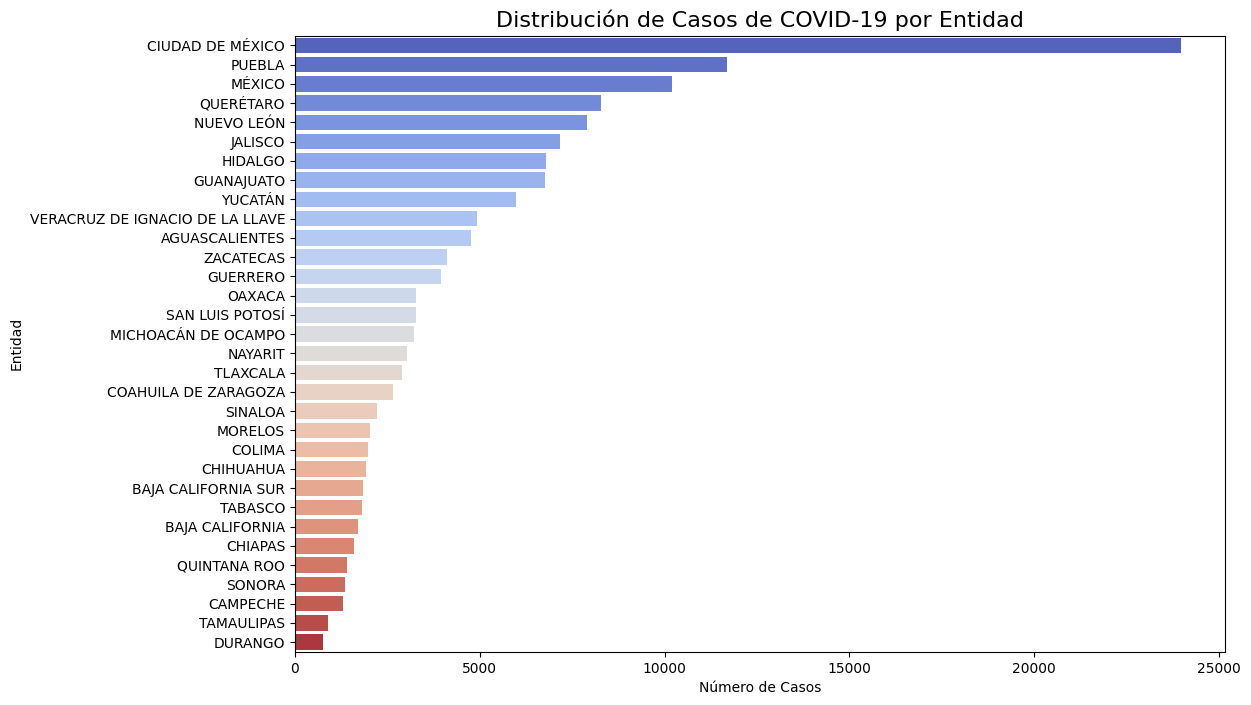

,Entidad,Total Casos
0,CIUDAD DE MÉXICO,23957
1,PUEBLA,11686
2,MÉXICO,10190
3,QUERÉTARO,8269
4,NUEVO LEÓN,7912


In [ ]:
casos_por_entidad = df_covid19V2['ENTIDAD_RES'].value_counts().reset_index()
casos_por_entidad.columns = ['Entidad', 'Total Casos']

# Visualizamos la distribución de casos por entidad
plt.figure(figsize=(12, 8))
sns.barplot(x='Total Casos', y='Entidad', data=casos_por_entidad, palette='coolwarm')
plt.title('Distribución de Casos de COVID-19 por Entidad', fontsize=16)
plt.xlabel('Número de Casos')
plt.ylabel('Entidad')
plt.savefig('Distribución de casos de Covid-19 por entidad.png', dpi=300)
plt.show()

# Mostrar la tabla de casos por entidad
casos_por_entidad.head()

# Tendencia temporal de ingresos, inicio de síntomas y defunción

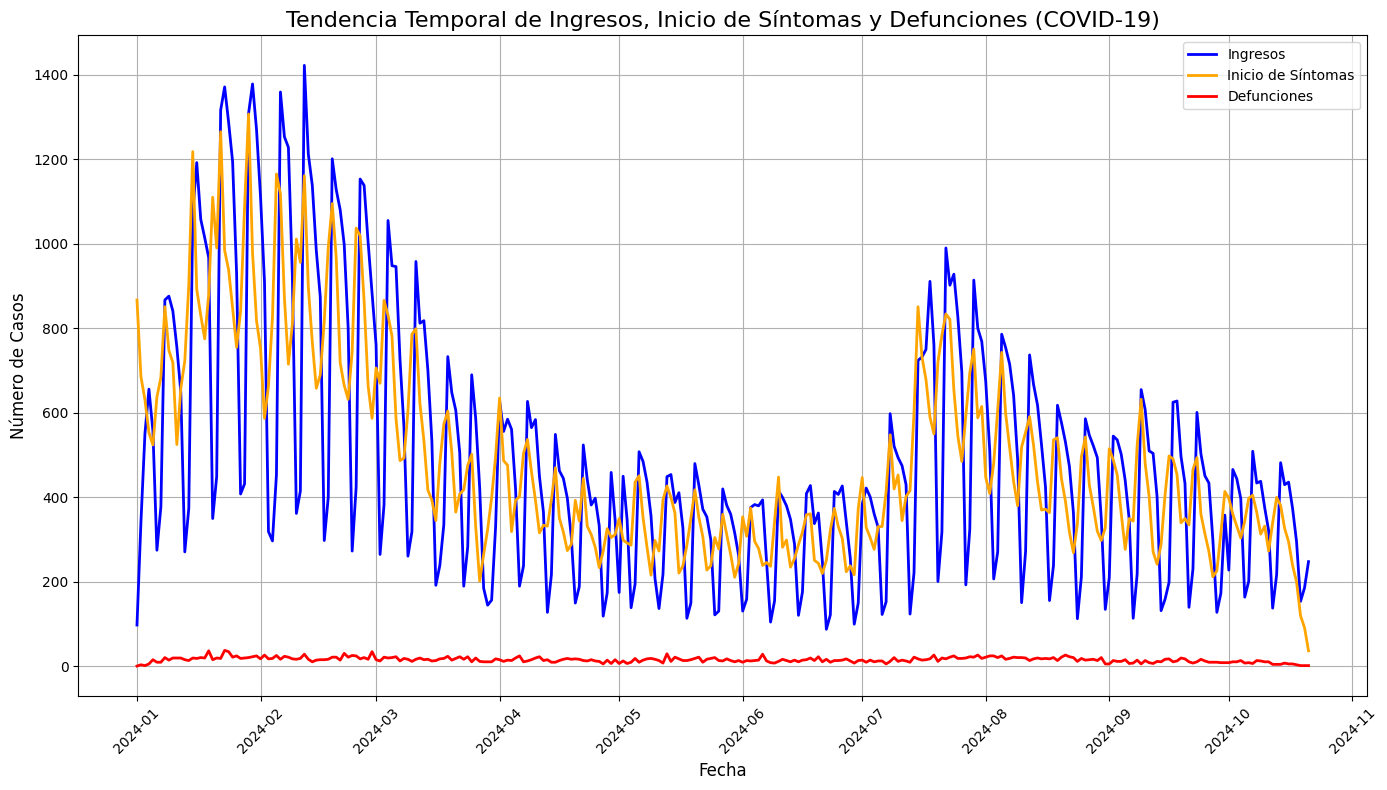

In [ ]:
# Agrupamos los datos por fecha y contamos el número de ocurrencias para cada evento (ingresos, síntomas, defunciones)
ingresos_por_dia = df_covid19V2['FECHA_INGRESO'].value_counts().sort_index()
sintomas_por_dia = df_covid19V2['FECHA_SINTOMAS'].value_counts().sort_index()
defunciones_por_dia = df_covid19V2['FECHA_DEF'].value_counts().sort_index()

# Graficamos las tendencias temporales de ingresos, inicio de síntomas y defunciones
plt.figure(figsize=(14, 8))

# Ingresos
plt.plot(ingresos_por_dia.index, ingresos_por_dia.values, label='Ingresos', color='blue', linewidth=2)

# Inicio de síntomas
plt.plot(sintomas_por_dia.index, sintomas_por_dia.values, label='Inicio de Síntomas', color='orange', linewidth=2)

# Defunciones
plt.plot(defunciones_por_dia.index, defunciones_por_dia.values, label='Defunciones', color='red', linewidth=2)

# Ajustes finales del gráfico
plt.title('Tendencia Temporal de Ingresos, Inicio de Síntomas y Defunciones (COVID-19)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Tendencia temporal de ingresos, inicio de sintomas y defunciones.png', dpi=300)
plt.show()

#  Información sobre el género de los individuos infectados.

Distribución de casos por género:
SEXO
Hombre    83636
Mujer     62075
Name: count, dtype: int64


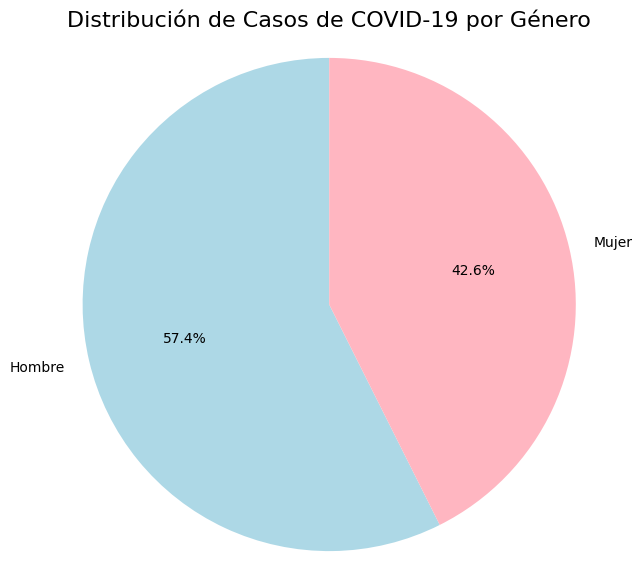

In [ ]:
# Contamos el número de casos por género (columna 'SEXO')
# Asegúrate de que 'SEXO' está limpio con etiquetas 'Hombre' y 'Mujer'
casos_por_genero = df_covid19V2['SEXO'].value_counts()

# Imprimimos la distribución de casos por género
print("Distribución de casos por género:")
print(casos_por_genero)

# Visualizamos la distribución de casos por género en un gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(casos_por_genero, labels=casos_por_genero.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightpink'])
plt.title('Distribución de Casos de COVID-19 por Género', fontsize=16)
plt.axis('equal')  # Asegura que el gráfico de pastel sea circular
plt.savefig('Distribución de Casos de COVID-19 por género.png', dpi=300)
plt.show()

# Información sobre los individuos que ingresaron a cuidados intensivos.

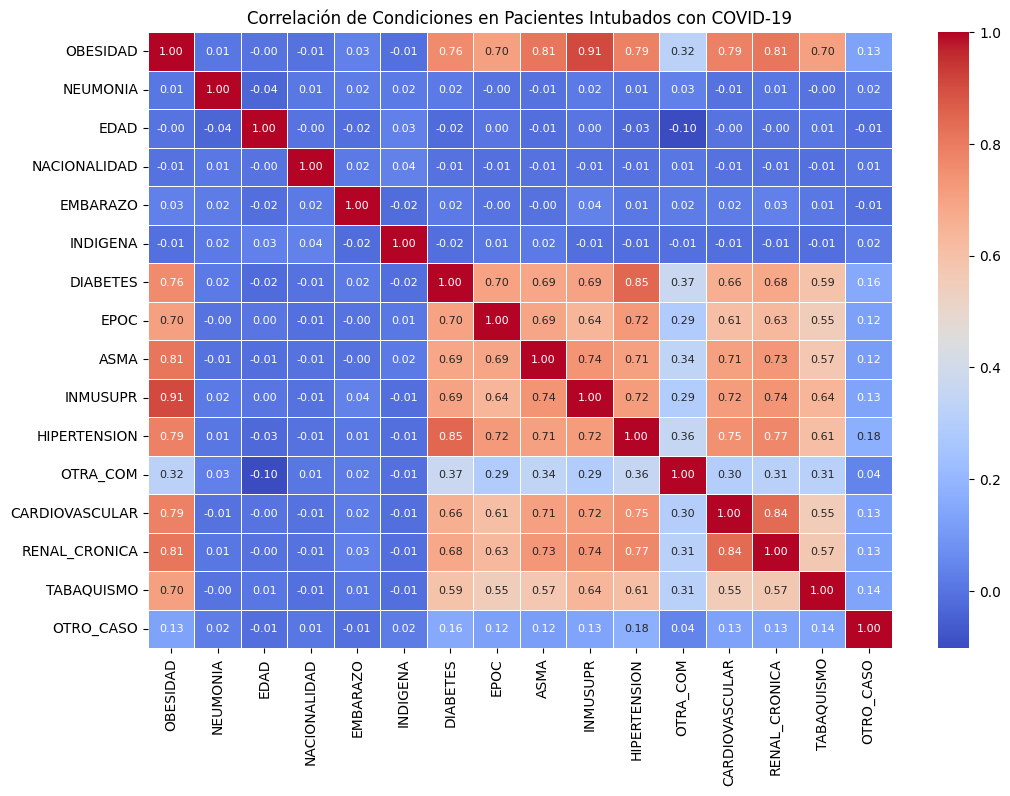

In [ ]:
# Filtrar pacientes intubados
df_covid19V2_intubado = df_covid19V2[df_covid19V2['INTUBADO'] == 1]  # Usamos 1 para "Sí"

# Seleccionar las columnas de interés
df_covid19V2_resultado = df_covid19V2_intubado[['OBESIDAD', 'NEUMONIA', 'EDAD',
                                                'NACIONALIDAD', 'EMBARAZO', 'INDIGENA', 'DIABETES',
                                                'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION', 'OTRA_COM',
                                                'CARDIOVASCULAR', 'RENAL_CRONICA', 'TABAQUISMO', 'OTRO_CASO']]

# Reemplazar valores específicos por NaN
df_covid19V2_resultado = df_covid19V2_resultado.replace(['Se ignora', 'No Aplica', 'No especificado'], np.nan)

# Eliminar filas con valores NaN
df_covid19V2_resultado_clean = df_covid19V2_resultado.dropna()

# Crear el heatmap de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df_covid19V2_resultado_clean.corr(), annot=True,annot_kws={"size": 8}, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title('Correlación de Condiciones en Pacientes Intubados con COVID-19')
plt.savefig('Correlacion_Condiciones_Pacientes_Intubados_COVID19.png', dpi=300)
plt.show()


#  Relación entre las comorbilidades y los infectados.